# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = 'dataset/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'
TEST_FILE = DATA_DIR + 'test.csv' # Hoặc tên file test của bạn trong thư mục dataset

In [120]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2 — Load & Inspect Data

In [122]:
import pandas as pd

# Ví dụ: r'D:\Datathon VinUni\Data set\sales.csv'
TRAIN_FILE = 'sales.csv' 
TEST_FILE = 'sample_submission.csv' # Đây là file mẫu cho phần test

# Load dữ liệu và ép kiểu ngày tháng ngay từ đầu
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test = pd.read_csv(TEST_FILE, parse_dates=['Date'])

# In ra kiểm tra
print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '->', train['Date'].max().date())
print()
print('Test shape:', test.shape)
# Nếu file test là sample_submission thì có thể không có cột Date, 
# Thư hãy check lại file thực tế của mình nhé
try:
    print('Test date range:', test['Date'].min().date(), '->', test['Date'].max().date())
except:
    print('Test file does not have a Date column yet')

print()
display(train.tail()) # Dùng display nhìn bảng sẽ đẹp hơn print

Train shape: (3833, 3)
Train date range: 2012-07-04 -> 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 -> 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


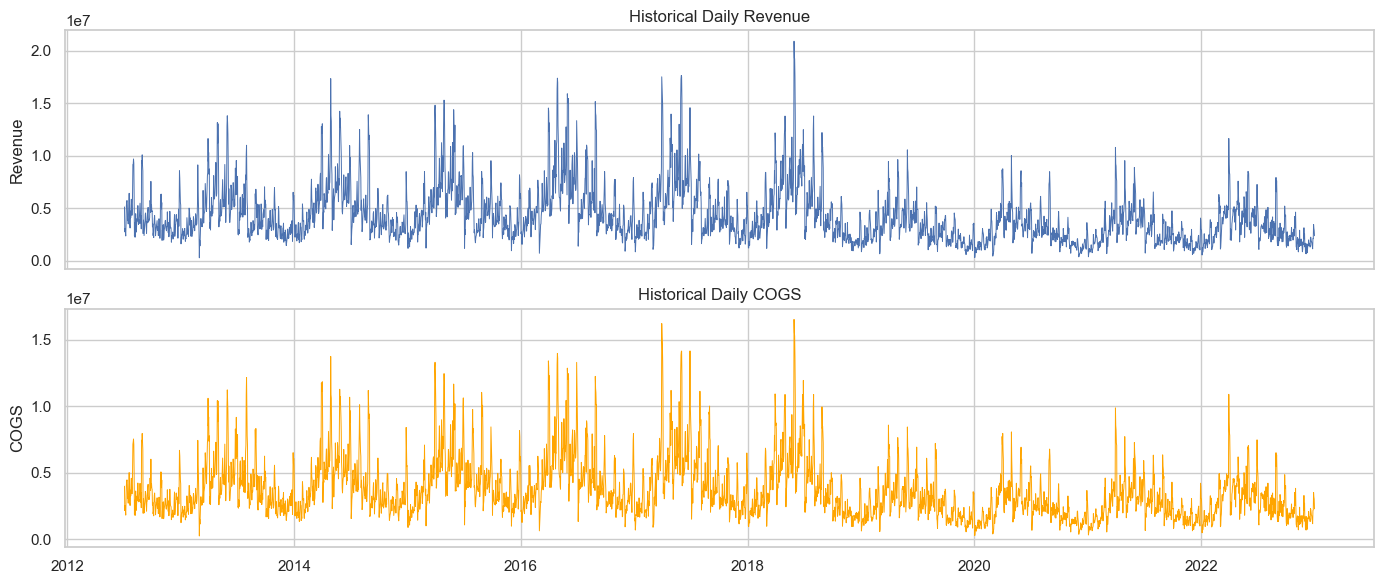

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [124]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [125]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [126]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

Seasonal profile rows: 366


,month,day,rev_norm,cogs_norm
0,1,1,0.864547,0.938006
1,1,2,0.415165,0.423207
2,1,3,0.329503,0.306372
3,1,4,0.370727,0.340570
4,1,5,0.400993,0.366576
5,1,6,0.418113,0.387441
6,1,7,0.444529,0.416864
7,1,8,0.457043,0.425623
8,1,9,0.481326,0.454805
9,1,10,0.509432,0.468719


## 5 — Predict Test Period

In [127]:
# Base level: 2022 annual mean (most recent complete year)
base_rev  = annual.loc[2022, 'Revenue']  / 365
base_cogs = annual.loc[2022, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

Các cột sau khi merge: ['Date', 'Revenue', 'COGS', 'year', 'day_of_year', 'month', 'day', 'rev_norm_x', 'cogs_norm_x', 'rev_norm_y', 'cogs_norm_y', 'rev_norm', 'cogs_norm']
MAPE Revenue (2021–2022): 25.53%
MAPE COGS    (2021–2022): 23.49%


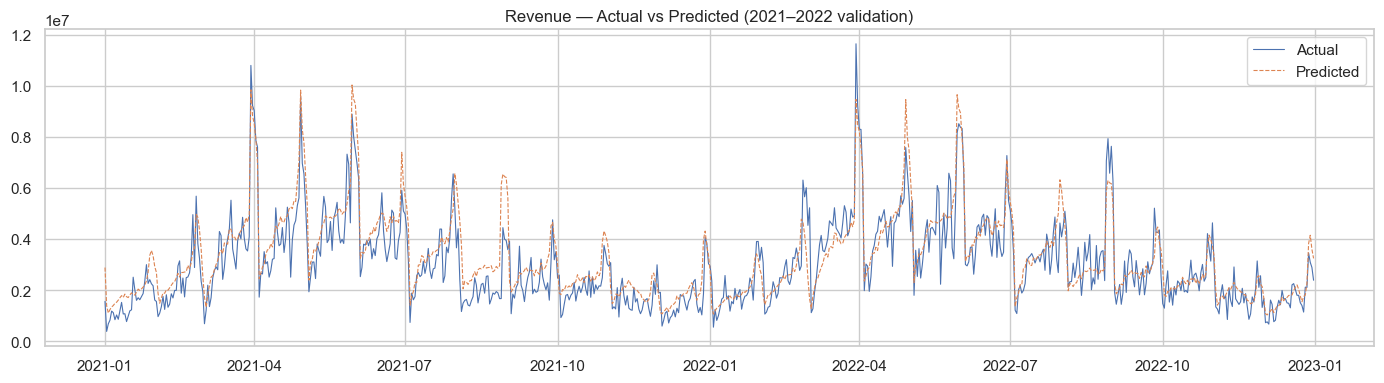

In [128]:
val = train[train['year'].isin([2021, 2022])].copy()
val = val.merge(seasonal, on=['month', 'day'], how='left')
# 1. Ép kiểu month và day ở cả 2 bảng về kiểu số nguyên (int)
val['month'] = val['month'].astype(int)
val['day']   = val['day'].astype(int)

seasonal['month'] = seasonal['month'].astype(int)
seasonal['day']   = seasonal['day'].astype(int)

# 2. Sau đó mới thực hiện merge
val = val.merge(seasonal, on=['month', 'day'], how='left')

# 3. Kiểm tra xem cột rev_norm đã sang chưa
print("Các cột sau khi merge:", val.columns.tolist())
val['rev_norm']  = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
val['years_ahead'] = val['year'] - 2022  # negative for historical
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2021–2022): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2021–2022): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue — Actual vs Predicted (2021–2022 validation)')
ax.legend(); plt.tight_layout(); plt.show()

In [129]:
print(seasonal.columns)

Index(['month', 'day', 'rev_norm', 'cogs_norm'], dtype='str')


## 7 — Export Submission

In [130]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
import os

# Lấy tên thư mục từ biến OUT_FILE (giả sử là 'dataset')
output_dir = os.path.dirname(OUT_FILE)

# Nếu thư mục không tồn tại và không phải là thư mục gốc
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Đã tạo thư mục: {output_dir}")

# Bây giờ mới lưu file
submission.to_csv(OUT_FILE, index=False)
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 548 rows to dataset/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


In [131]:
import pandas as pd

df_orders = pd.read_csv('orders.csv') 
df_orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [132]:
import pandas as pd

df_orders = pd.read_csv('orders.csv')

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

df_orders = df_orders.sort_values(['customer_id', 'order_date'])

df_orders['inter_order_gap'] = df_orders.groupby('customer_id')['order_date'].diff().dt.days

result = df_orders['inter_order_gap'].median()

print(f"{result:.0f} ngày")

144 ngày


In [133]:
import pandas as pd
web_traffic = pd.read_csv('web_traffic.csv')

#  chỉ số Pages per Session 
web_traffic['pages_per_session'] = web_traffic['page_views'] / web_traffic['sessions']

#  Summary theo Source (
summary_df = web_traffic.groupby('traffic_source').agg({
    'pages_per_session': 'mean',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean' 
}).reset_index()

# rename
summary_df.columns = ['source', 'avg_pages', 'avg_bounce', 'avg_duration']

In [134]:
# chuẩn hóa real engagement
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_norm = ['avg_pages', 'avg_bounce', 'avg_duration']
summary_df[[f'{c}_norm' for c in cols_to_norm]] = scaler.fit_transform(summary_df[cols_to_norm])

# tính score
summary_df['real_engagement_score'] = (
    summary_df['avg_pages_norm'] * summary_df['avg_duration_norm'] * (1 - summary_df['avg_bounce_norm'])
)

# phân loại
summary_df['engagement_type'] = summary_df['real_engagement_score'].apply(
    lambda x: 'REAL' if x > summary_df['real_engagement_score'].median() else 'FAKE'
)

display(summary_df[['source', 'real_engagement_score', 'engagement_type']].sort_values(by='real_engagement_score', ascending=False))

,source,real_engagement_score,engagement_type
1,email_campaign,0.068850,REAL
3,paid_search,0.030706,REAL
2,organic_search,0.007721,REAL
0,direct,0.000000,FAKE
4,referral,0.000000,FAKE
5,social_media,0.000000,FAKE


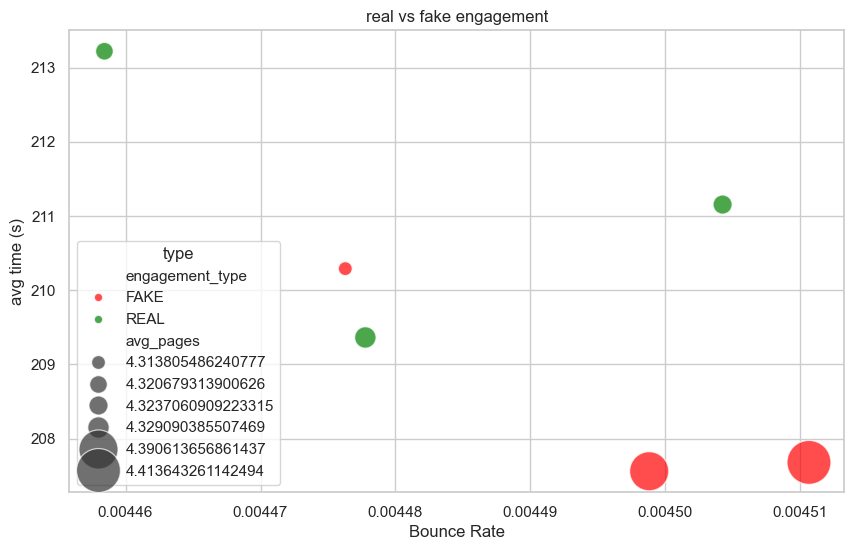

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary_df, 
                x='avg_bounce', 
                y='avg_duration', 
                size='avg_pages', 
                hue='engagement_type',
                palette={'REAL': 'green', 'FAKE': 'red'},
                sizes=(100, 1000), alpha=0.7)

plt.title('real vs fake engagement')
plt.xlabel('Bounce Rate')
plt.ylabel('avg time (s)')
plt.legend(title='type')
plt.grid(True)
plt.show()

In [136]:
import pandas as pd

web_traffic = pd.read_csv('web_traffic.csv')

web_traffic['bounce_count'] = web_traffic['bounce_rate'] * web_traffic['sessions']

summary_table = web_traffic.groupby('traffic_source').agg({
    'bounce_count': 'sum',
    'sessions': 'sum',
    'bounce_rate': 'mean' 
}).reset_index()

summary_table['weighted_avg_bounce'] = summary_table['bounce_count'] / summary_table['sessions']

target_sources = ['organic_search', 'paid_search', 'referral']
final_result = summary_table[summary_table['traffic_source'].isin(target_sources)]


final_result = final_result.rename(columns={
    'bounce_rate': 'simple_avg_bounce',
    'traffic_source': 'Source'
})

display(final_result[['Source', 'simple_avg_bounce', 'weighted_avg_bounce']])

,Source,simple_avg_bounce,weighted_avg_bounce
2,organic_search,0.004504,0.004498
3,paid_search,0.004478,0.004479
4,referral,0.004499,0.004527


In [137]:

print("Top 5 tỷ lệ thoát cao nhất:")
print(web_traffic.nlargest(5, 'bounce_rate')[['date', 'traffic_source', 'bounce_rate']])

total_sessions = web_traffic['sessions'].sum()
total_bounces = (web_traffic['bounce_rate'] * web_traffic['sessions']).sum()
print(f"\nTổng Sessions: {total_sessions}")
print(f"Tổng số lần thoát tính toán: {total_bounces}")

Top 5 tỷ lệ thoát cao nhất:
            date  traffic_source  bounce_rate
180   2013-06-30  organic_search       0.0058
626   2014-09-19  organic_search       0.0058
1560  2017-04-10  email_campaign       0.0058
2939  2021-01-18  organic_search       0.0058
3005  2021-03-25     paid_search       0.0058

Tổng Sessions: 91452537
Tổng số lần thoát tính toán: 410254.76912000007


In [138]:
import pandas as pd
import numpy as np

#  data load
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')
geography = pd.read_csv('geography.csv')
promotions = pd.read_csv('promotions.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
returns = pd.read_csv('returns.csv')
shipments = pd.read_csv('shipments.csv')

web_traffic = pd.read_csv('web_traffic.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])


In [139]:

#  Baseline
summary_metrics = returns.agg(
    total_returns=('return_id', 'count'),
    total_qty=('return_quantity', 'sum'),
    total_refund=('refund_amount', 'sum'),
    avg_refund=('refund_amount', 'mean')
).reset_index()

#  Frequency
reason_analysis = returns.groupby('return_reason').agg(
    cnt=('return_id', 'count')
).sort_values(by='cnt', ascending=False).reset_index()

display(summary_metrics, reason_analysis)

,index,return_id,return_quantity,refund_amount
0,total_returns,39939.0,NaN,NaN
1,total_qty,NaN,109586.0,NaN
2,total_refund,NaN,NaN,5.105985e+08
3,avg_refund,NaN,NaN,1.278446e+04


,return_reason,cnt
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


In [140]:
#qan&finance
reason_impact = returns.groupby('return_reason').agg(
    total_qty=('return_quantity', 'sum'),
    total_refund=('refund_amount', 'sum')
).sort_values(by='total_refund', ascending=False).reset_index()

display(reason_impact)

,return_reason,total_qty,total_refund
0,wrong_size,38042,1.766872e+08
1,defective,22274,1.035991e+08
2,not_as_described,19358,9.065319e+07
3,changed_mind,19144,8.972176e+07
4,late_delivery,10768,4.993721e+07


In [141]:
import numpy as np
# đk phân chia
conditions = [
    returns['return_reason'].isin(['defective', 'not_as_described']),
    returns['return_reason'] == 'changed_mind',
    returns['return_reason'] == 'late_delivery',
    returns['return_reason'] == 'wrong_size'
]
choices = ['product_issue', 'customer_issue', 'operation_issue', 'fit_issue']

returns['return_type'] = np.select(conditions, choices, default='other')

type_analysis = returns.groupby('return_type').agg(
    cnt=('return_id', 'count'),
    refund=('refund_amount', 'sum')
).reset_index()

display(type_analysis)

,return_type,cnt,refund
0,customer_issue,6931,8.972176e+07
1,fit_issue,13967,1.766872e+08
2,operation_issue,3986,4.993721e+07
3,product_issue,15055,1.942523e+08


In [142]:
# theo product
product_return_analysis = returns.groupby('product_id').agg(
    return_cnt=('return_id', 'count'),
    qty=('return_quantity', 'sum'),
    refund=('refund_amount', 'sum')
).merge(products, on='product_id').sort_values(by='refund', ascending=False)

display(product_return_analysis.head(10))

,product_id,return_cnt,qty,refund,product_name,category,segment,size,color,price,cogs
223,487,415,1129,12241878.26,SaigonFlex UM-92,Streetwear,Balanced,XL,silver,13019.799122,11027.769856
455,826,360,996,10879460.50,HanoiStreet UM-10,Streetwear,Balanced,L,green,12730.405428,12093.885157
192,438,375,971,9654909.83,SaigonFlex UM-43,Streetwear,Balanced,L,pink,11718.531191,6680.734632
215,475,265,733,7958581.64,SaigonFlex UM-80,Streetwear,Balanced,XL,purple,12606.228520,10040.861016
227,491,273,754,7121041.39,SaigonFlex UM-96,Streetwear,Balanced,XL,black,11060.080545,10507.076517
317,604,441,1169,6113477.47,SaigonFlex UC-69,Streetwear,Everyday,S,white,6135.298831,4141.940241
1238,2331,340,935,5868240.11,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431
321,609,217,638,5729880.67,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
1239,2332,402,1139,5687513.09,VietMotion UE-06,Streetwear,Performance,S,orange,5799.628950,4554.448615
198,449,192,532,5672410.38,SaigonFlex UM-54,Streetwear,Balanced,M,yellow,12600.871631,11279.040197


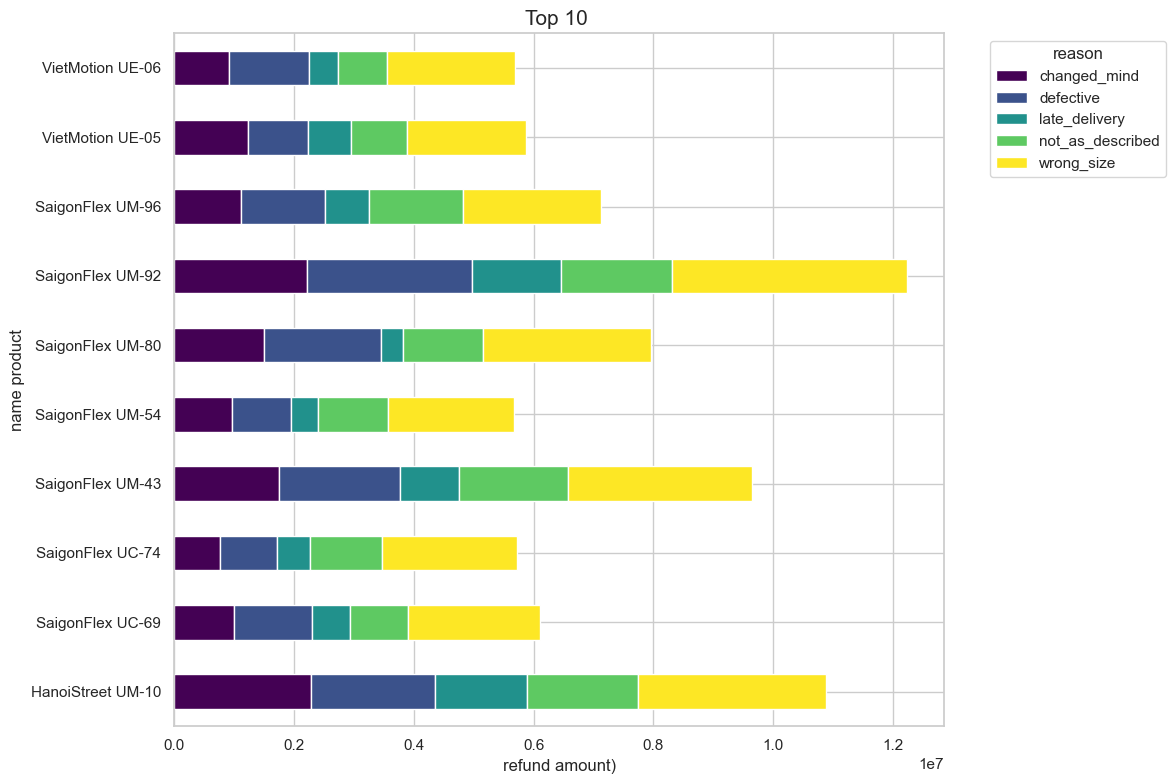

In [143]:
#top 10 refund
import matplotlib.pyplot as plt
import seaborn as sns

top_10_refund = returns.groupby('product_id')['refund_amount'].sum().nlargest(10).index
# top 10
plot_data = returns[returns['product_id'].isin(top_10_refund)].merge(products[['product_id', 'product_name']], on='product_id')

pivot_df = plot_data.groupby(['product_name', 'return_reason'])['refund_amount'].sum().unstack().fillna(0)

pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Top 10 ', fontsize=15)
plt.xlabel('refund amount)')
plt.ylabel('name product')
plt.legend(title='reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

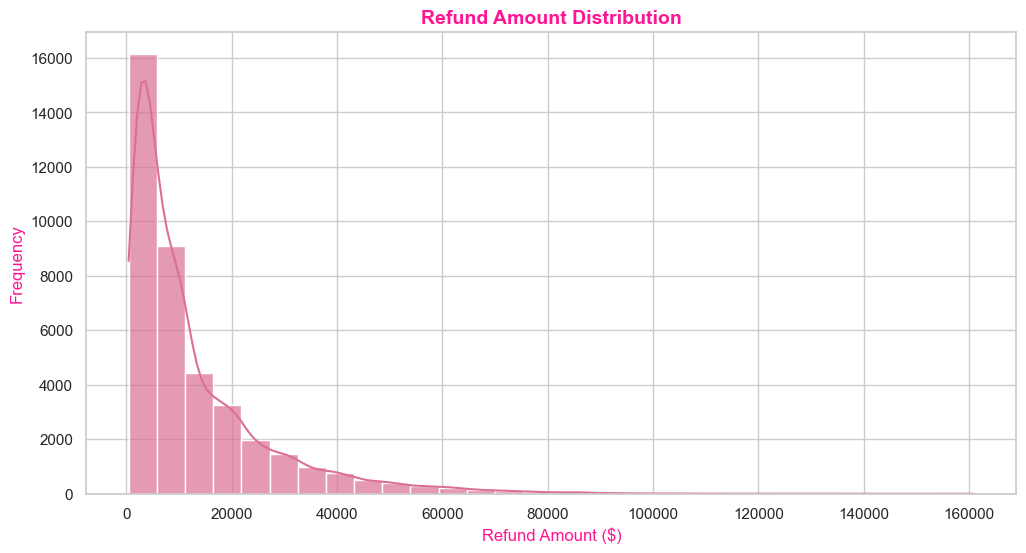

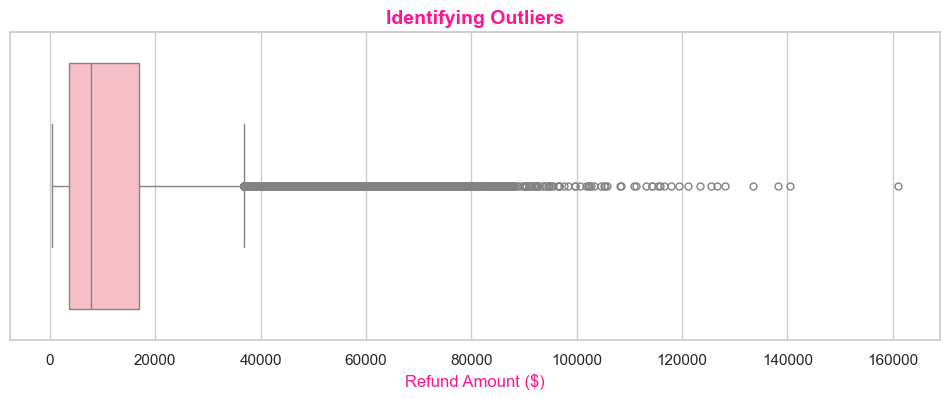

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.histplot(returns['refund_amount'], kde=True, color='palevioletred', bins=30, alpha=0.7)

plt.title('Refund Amount Distribution', fontsize=14, fontweight='bold', color='deeppink')
plt.xlabel('Refund Amount ($)', color='deeppink')
plt.ylabel('Frequency', color='deeppink')
plt.show()

plt.figure(figsize=(12, 4))
sns.boxplot(x=returns['refund_amount'], color='lightpink', fliersize=5)

plt.title('Identifying Outliers', fontsize=14, fontweight='bold', color='deeppink')
plt.xlabel('Refund Amount ($)', color='deeppink')
plt.show()

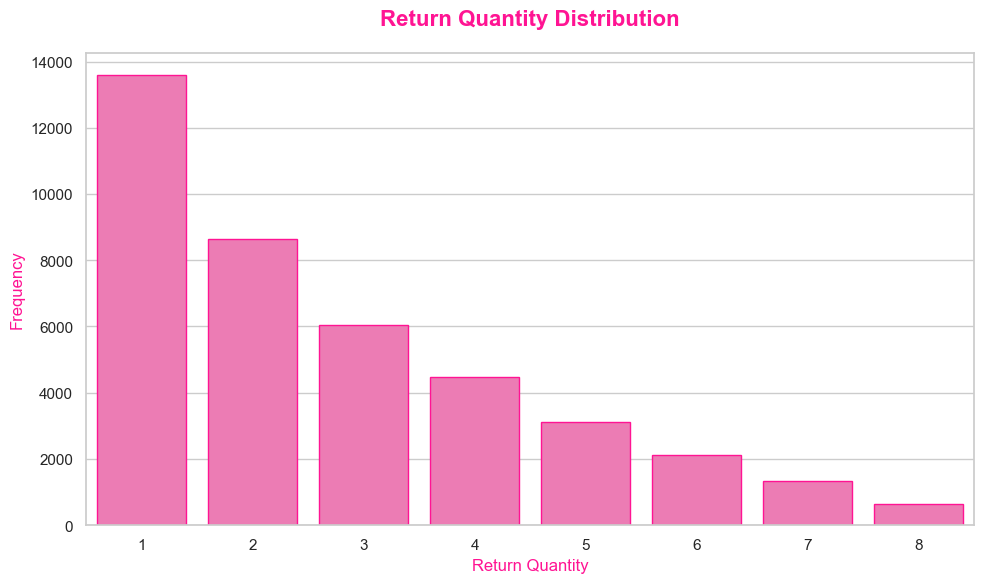

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))


sns.countplot(data=returns, x='return_quantity', color='hotpink', edgecolor='deeppink', linewidth=1)

plt.title('Return Quantity Distribution', 
          fontsize=16, fontweight='bold', color='deeppink', pad=20)
plt.xlabel('Return Quantity', fontsize=12, color='deeppink')
plt.ylabel('Frequency', fontsize=12, color='deeppink')


plt.tight_layout() 
plt.show()

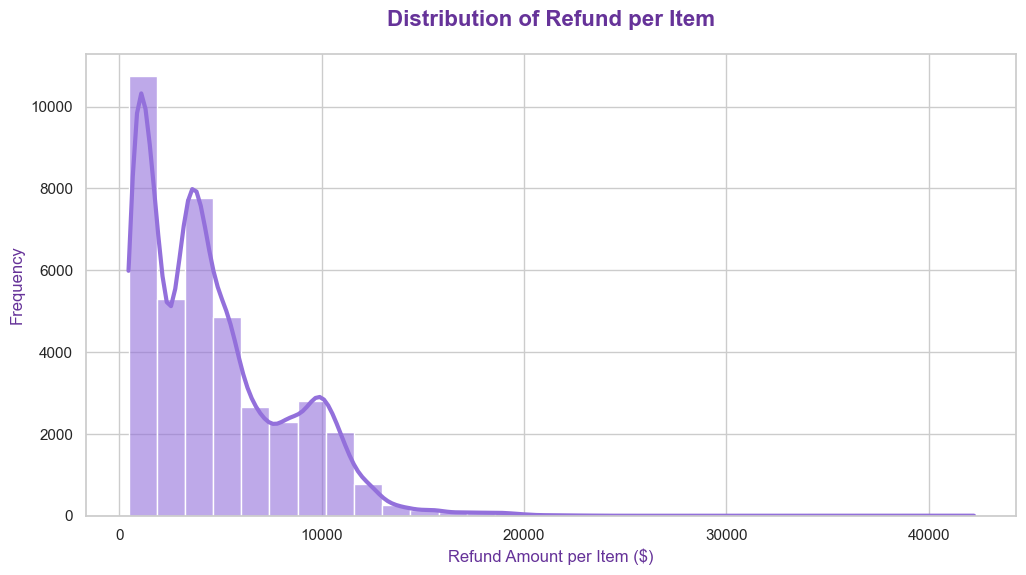

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

returns['refund_per_item'] = returns['refund_amount'] / returns['return_quantity']

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(returns['refund_per_item'], kde=True, 
             color='mediumpurple', 
             line_kws={'color': 'rebeccapurple', 'linewidth': 3}, 
             bins=30, alpha=0.6)

plt.title('Distribution of Refund per Item', fontsize=16, fontweight='bold', color='rebeccapurple', pad=20)
plt.xlabel('Refund Amount per Item ($)', fontsize=12, color='rebeccapurple')
plt.ylabel('Frequency', fontsize=12, color='rebeccapurple')
plt.show()

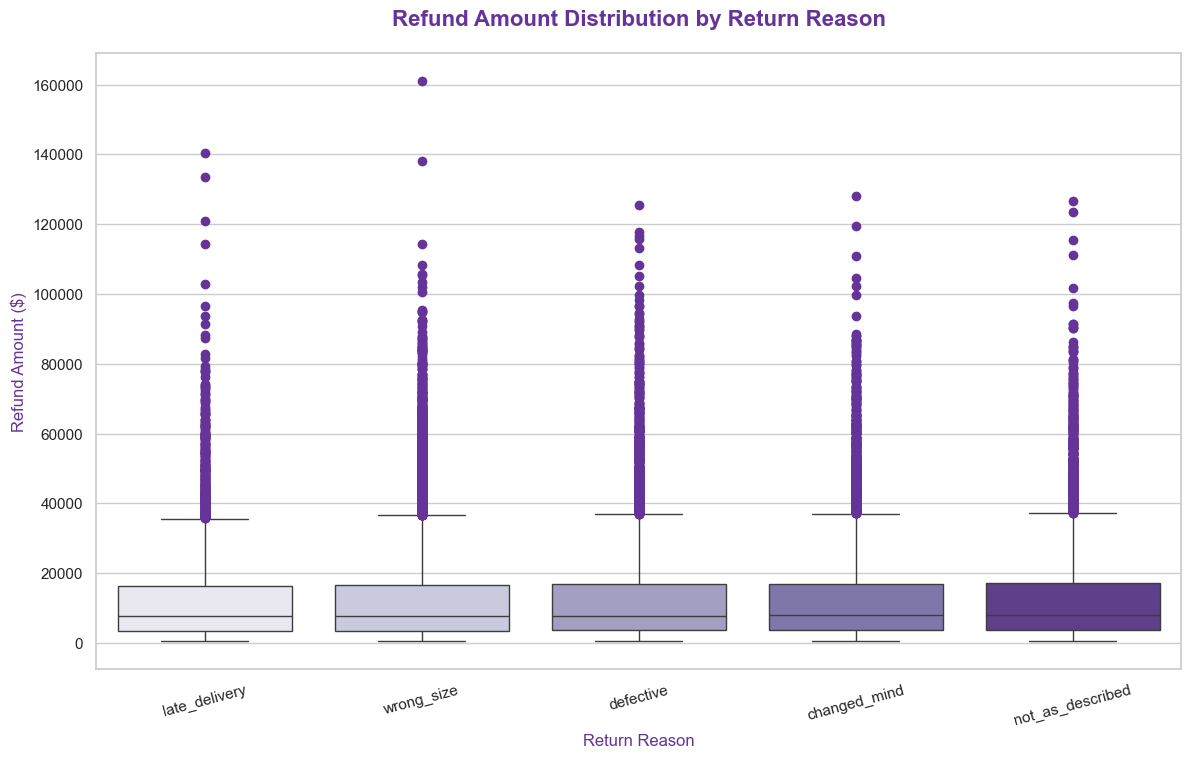

In [147]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=returns, x='return_reason', y='refund_amount', 
            palette='Purples', 
            flierprops={"markerfacecolor": "rebeccapurple", "markeredgecolor": "rebeccapurple"})

plt.title('Refund Amount Distribution by Return Reason', fontsize=16, fontweight='bold', color='rebeccapurple', pad=20)
plt.xlabel('Return Reason', fontsize=12, color='rebeccapurple')
plt.ylabel('Refund Amount ($)', fontsize=12, color='rebeccapurple')

plt.xticks(rotation=15)
plt.show()

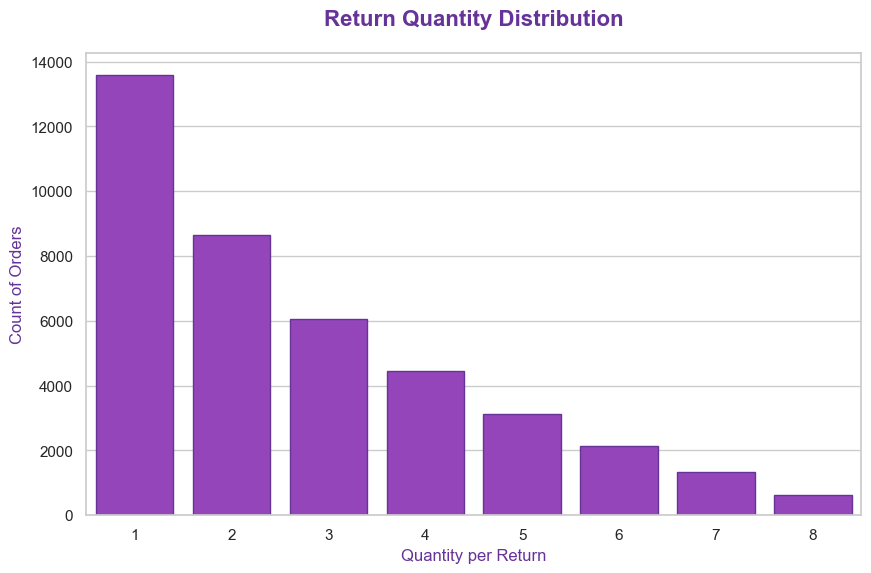

In [148]:
plt.figure(figsize=(10, 6))


sns.countplot(data=returns, x='return_quantity', color='darkorchid', edgecolor='rebeccapurple')

plt.title('Return Quantity Distribution', fontsize=16, fontweight='bold', color='rebeccapurple', pad=20)
plt.xlabel('Quantity per Return', fontsize=12, color='rebeccapurple')
plt.ylabel('Count of Orders', fontsize=12, color='rebeccapurple')

plt.show()

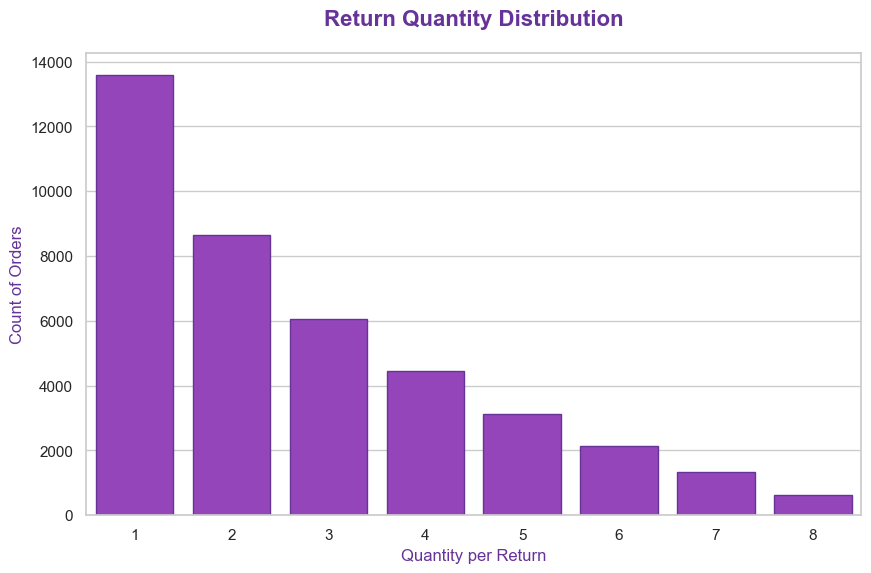

In [149]:
plt.figure(figsize=(10, 6))


sns.countplot(data=returns, x='return_quantity', color='darkorchid', edgecolor='rebeccapurple')

plt.title('Return Quantity Distribution', fontsize=16, fontweight='bold', color='rebeccapurple', pad=20)
plt.xlabel('Quantity per Return', fontsize=12, color='rebeccapurple')
plt.ylabel('Count of Orders', fontsize=12, color='rebeccapurple')

plt.show()

      product_id  line_revenue       product_name
308          487  3.982136e+08   SaigonFlex UM-92
566          826  3.422650e+08  HanoiStreet UM-10
272          438  3.407063e+08   SaigonFlex UM-43
298          475  2.673875e+08   SaigonFlex UM-80
312          491  2.518164e+08   SaigonFlex UM-96
410          604  2.079307e+08   SaigonFlex UC-69
327          506  2.018237e+08   SaigonFlex UM-11
279          449  1.852522e+08   SaigonFlex UM-54
1380        2045  1.850812e+08      UrbanVN UE-05
234          396  1.782019e+08   SaigonFlex UM-01


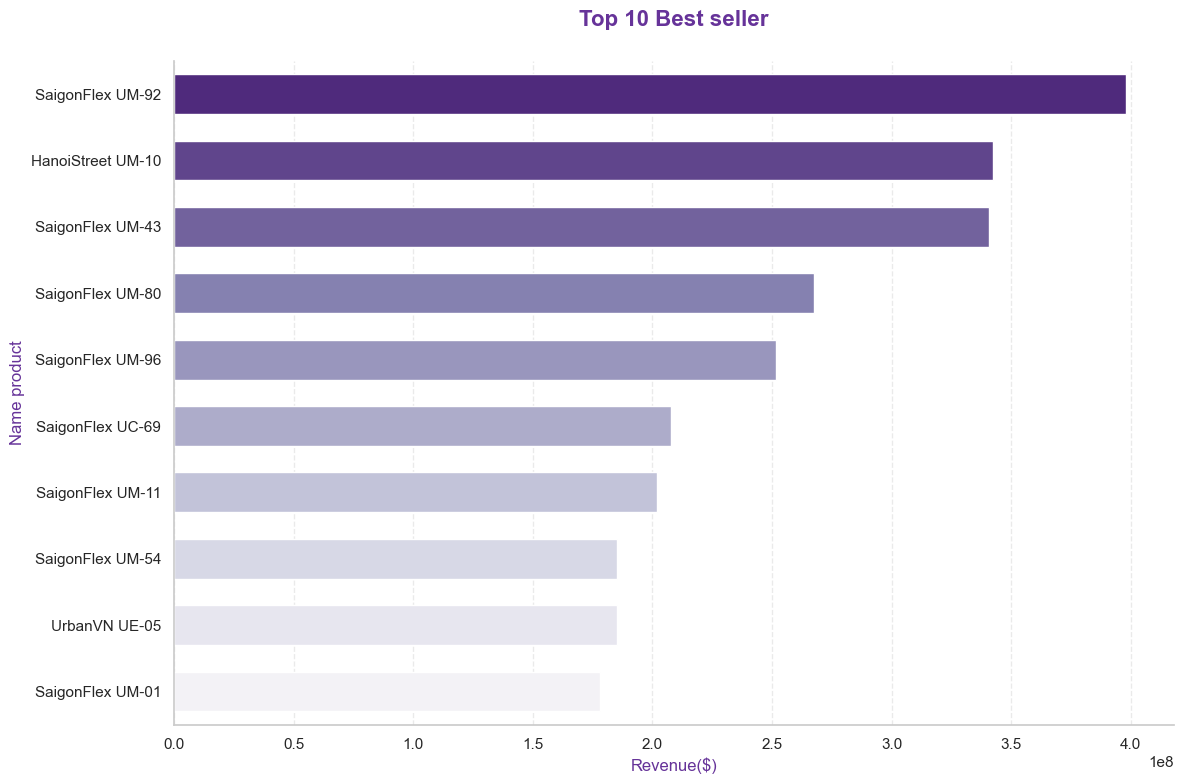

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_items.columns = order_items.columns.str.strip()
products.columns = products.columns.str.strip()

order_items['line_revenue'] = order_items['unit_price'] * order_items['quantity']
best_seller_data = order_items.groupby('product_id')['line_revenue'].sum().reset_index()


best_seller_named = pd.merge(best_seller_data, products[['product_id', 'product_name']], on='product_id', how='left')


top_10_final = best_seller_named.nlargest(10, 'line_revenue')

print(top_10_final)
plt.figure(figsize=(12, 8)) 
sns.barplot(data=top_10_final, x='line_revenue', y='product_name', 
            palette='Purples_r', width=0.6) 

plt.title('Top 10 Best seller', fontsize=16, fontweight='bold', color='rebeccapurple', pad=25)
plt.xlabel('Revenue($)', fontsize=12, color='rebeccapurple')
plt.ylabel('Name product', fontsize=12, color='rebeccapurple')

plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

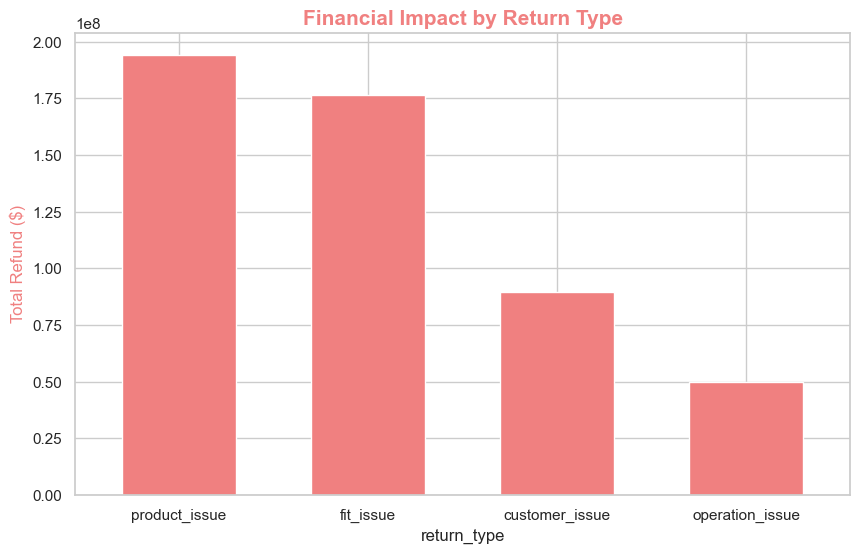

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def categorize_return(reason):
    if reason in ['defective', 'not_as_described']: return 'product_issue'
    if reason == 'changed_mind': return 'customer_issue'
    if reason == 'late_delivery': return 'operation_issue'
    if reason == 'wrong_size': return 'fit_issue'
    return 'other'

returns['return_type'] = returns['return_reason'].apply(categorize_return)

plt.figure(figsize=(10, 6))
type_counts = returns.groupby('return_type')['refund_amount'].sum().sort_values(ascending=False)
type_counts.plot(kind='bar', color='lightcoral', width=0.6)

plt.title('Financial Impact by Return Type', fontsize=15, fontweight='bold', color='lightcoral')
plt.ylabel('Total Refund ($)', color='lightcoral')
plt.xticks(rotation=0)
plt.show()

In [152]:
import pandas as pd
if 'sales_amount' not in order_items.columns:
    order_items['sales_amount'] = order_items['unit_price'] * order_items['quantity']

sales_data = order_items.groupby('product_id')['sales_amount'].sum().reset_index()

returns_data = returns.groupby('product_id')['refund_amount'].sum().reset_index()

performance_df = pd.merge(sales_data, returns_data, on='product_id', how='left').fillna(0)

performance_df['return_ratio'] = performance_df.apply(
    lambda x: x['refund_amount'] / x['sales_amount'] if x['sales_amount'] > 0 else 0, axis=1
)



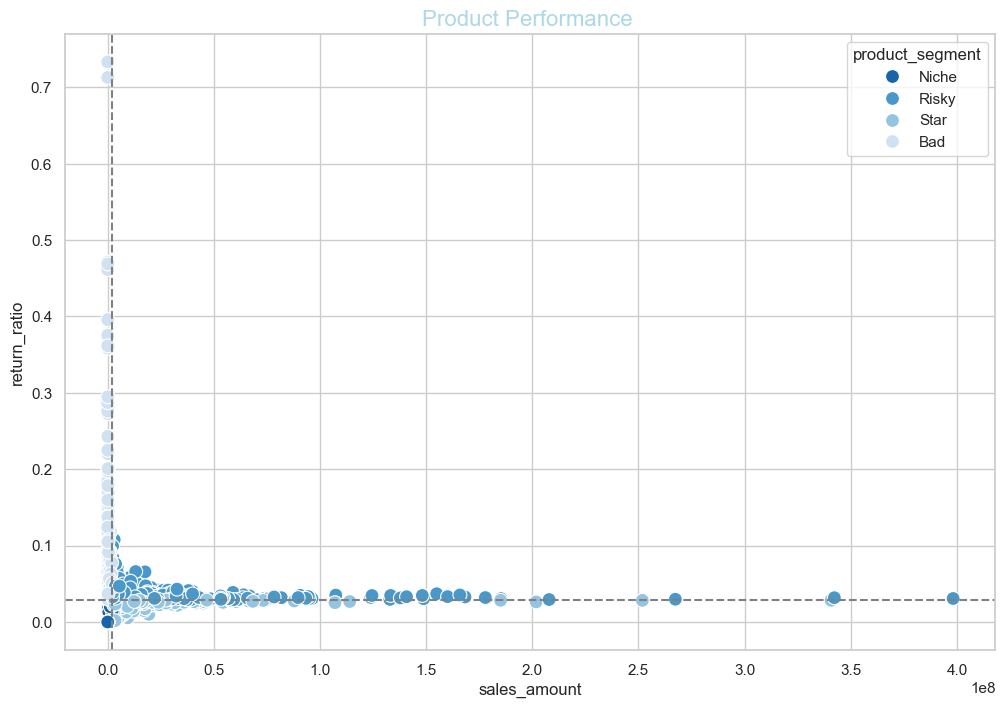

In [153]:

mean_sales = performance_df['sales_amount'].median()
mean_ratio = performance_df['return_ratio'].median()

def segment_product(row):
    if row['sales_amount'] > mean_sales:
        return 'Star' if row['return_ratio'] <= mean_ratio else 'Risky'
    else:
        return 'Niche' if row['return_ratio'] <= mean_ratio else 'Bad'

performance_df['product_segment'] = performance_df.apply(segment_product, axis=1)

# Vẽ biểu đồ Scatter Plot phân vùng
plt.figure(figsize=(12, 8))
sns.scatterplot(data=performance_df, x='sales_amount', y='return_ratio', 
                hue='product_segment', palette='Blues_r', s=100)

plt.axhline(mean_ratio, color='gray', linestyle='--')
plt.axvline(mean_sales, color='gray', linestyle='--')
plt.title('Product Performance ', fontsize=16, color='lightblue')
plt.show()

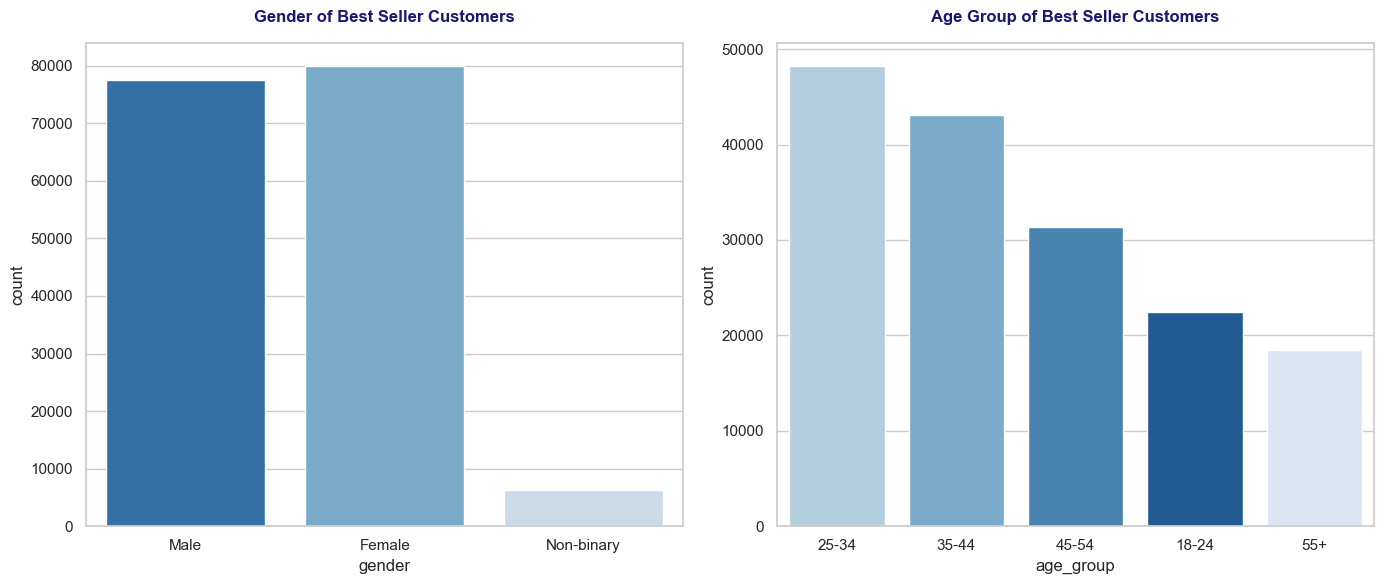

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

m_sales = performance_df['sales_amount'].median()
m_ratio = performance_df['return_ratio'].median()
star_list = performance_df[(performance_df['sales_amount'] > m_sales) & 
                           (performance_df['return_ratio'] <= m_ratio)]['product_id']


star_orders = order_items[order_items['product_id'].isin(star_list)]

order_cust = pd.merge(star_orders, orders[['order_id', 'customer_id']], on='order_id')


star_analysis = pd.merge(
    order_cust, 
    customers[['customer_id', 'gender', 'age_group']], 
    on='customer_id', 
    how='left',
    suffixes=('', '_duplicate')
)

if 'gender' not in star_analysis.columns and 'gender_x' in star_analysis.columns:
    star_analysis = star_analysis.rename(columns={'gender_x': 'gender', 'age_group_x': 'age_group'})

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.subplot(1, 2, 1)
sns.countplot(data=star_analysis, x='gender', palette='Blues_r', legend=False)
plt.title('Gender of Best Seller Customers', color='midnightblue', fontweight='bold', pad=15)

plt.subplot(1, 2, 2)
sns.countplot(data=star_analysis, x='age_group', palette='Blues_r', 
              order=star_analysis['age_group'].value_counts().index, hue='age_group', legend=False)
plt.title('Age Group of Best Seller Customers', color='midnightblue', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

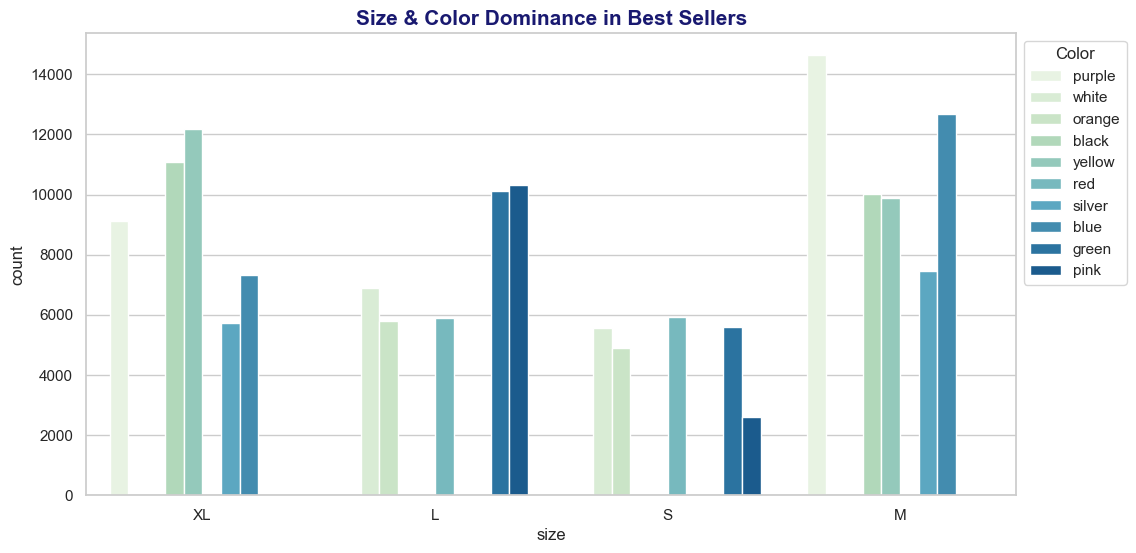

In [155]:

attr_df = pd.merge(star_orders, products[['product_id', 'size', 'color']], on='product_id')

plt.figure(figsize=(12, 6))
sns.countplot(data=attr_df, x='size', hue='color', palette='GnBu') # Xanh lục - Xanh biển

plt.title('Size & Color Dominance in Best Sellers', fontsize=15, color='midnightblue', fontweight='bold')
plt.legend(title='Color', bbox_to_anchor=(1, 1))
plt.show()

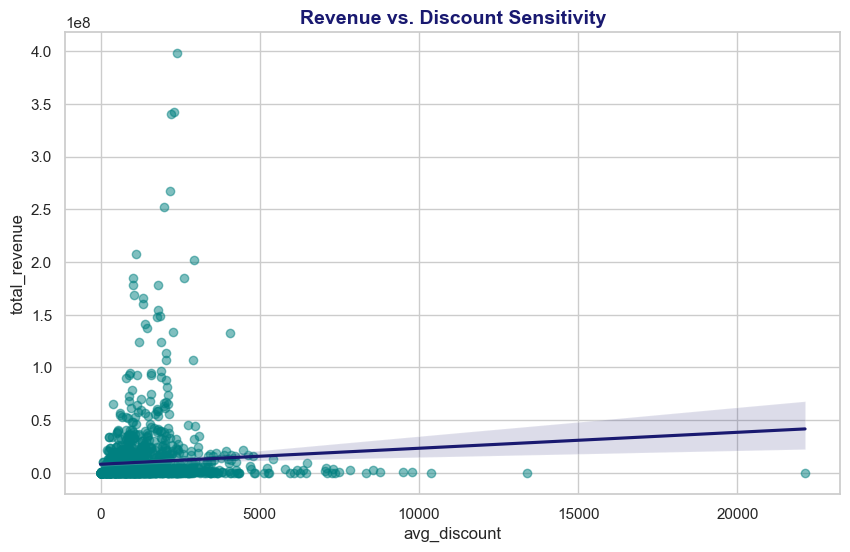

In [156]:

discount_perf = order_items.groupby('product_id').agg(
    avg_discount=('discount_amount', 'mean'),
    total_revenue=('line_revenue', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=discount_perf, x='avg_discount', y='total_revenue', 
            scatter_kws={'color':'teal', 'alpha':0.5}, line_kws={'color':'midnightblue'})

plt.title('Revenue vs. Discount Sensitivity', fontsize=14, color='midnightblue', fontweight='bold')
plt.show()

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


possible_zip_names = ['zip', 'zip_code', 'postal_code', 'postcode']
actual_zip_col = next((col for col in customer_analysis.columns if col in possible_zip_names), None)


if actual_zip_col is None:

    customer_analysis = pd.merge(customer_analysis, customers[['customer_id', 'zip']], on='customer_id', how='left')
    actual_zip_col = 'zip'

geo_analysis = pd.merge(
    customer_analysis, 
    geography, 
    left_on=actual_zip_col, 
    right_on='zip', 
)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.countplot(
    data=geo_analysis, 
    y='region', 
    palette='Blues_r', 
    order=geo_analysis['region'].value_counts().index,
    hue='region',
    legend=False
)

plt.title('Best Seller Performance by Region | The Gridbreakers', fontsize=16, fontweight='bold', color='midnightblue')
plt.xlabel('Number of Orders', color='midnightblue')
plt.ylabel('Region', color='midnightblue')

plt.tight_layout()
plt.show()

NameError: name 'customer_analysis' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders['order_date'] = pd.to_datetime(orders['order_date'])

orders['month'] = orders['order_date'].dt.to_period('M').astype(str)

sales_col = 'sales_amount' if 'sales_amount' in order_items.columns else 'line_revenue'
monthly_data = pd.merge(order_items, orders[['order_id', 'month']], on='order_id')

monthly_sales = monthly_data.groupby(['month', 'product_id'])[sales_col].sum().reset_index()

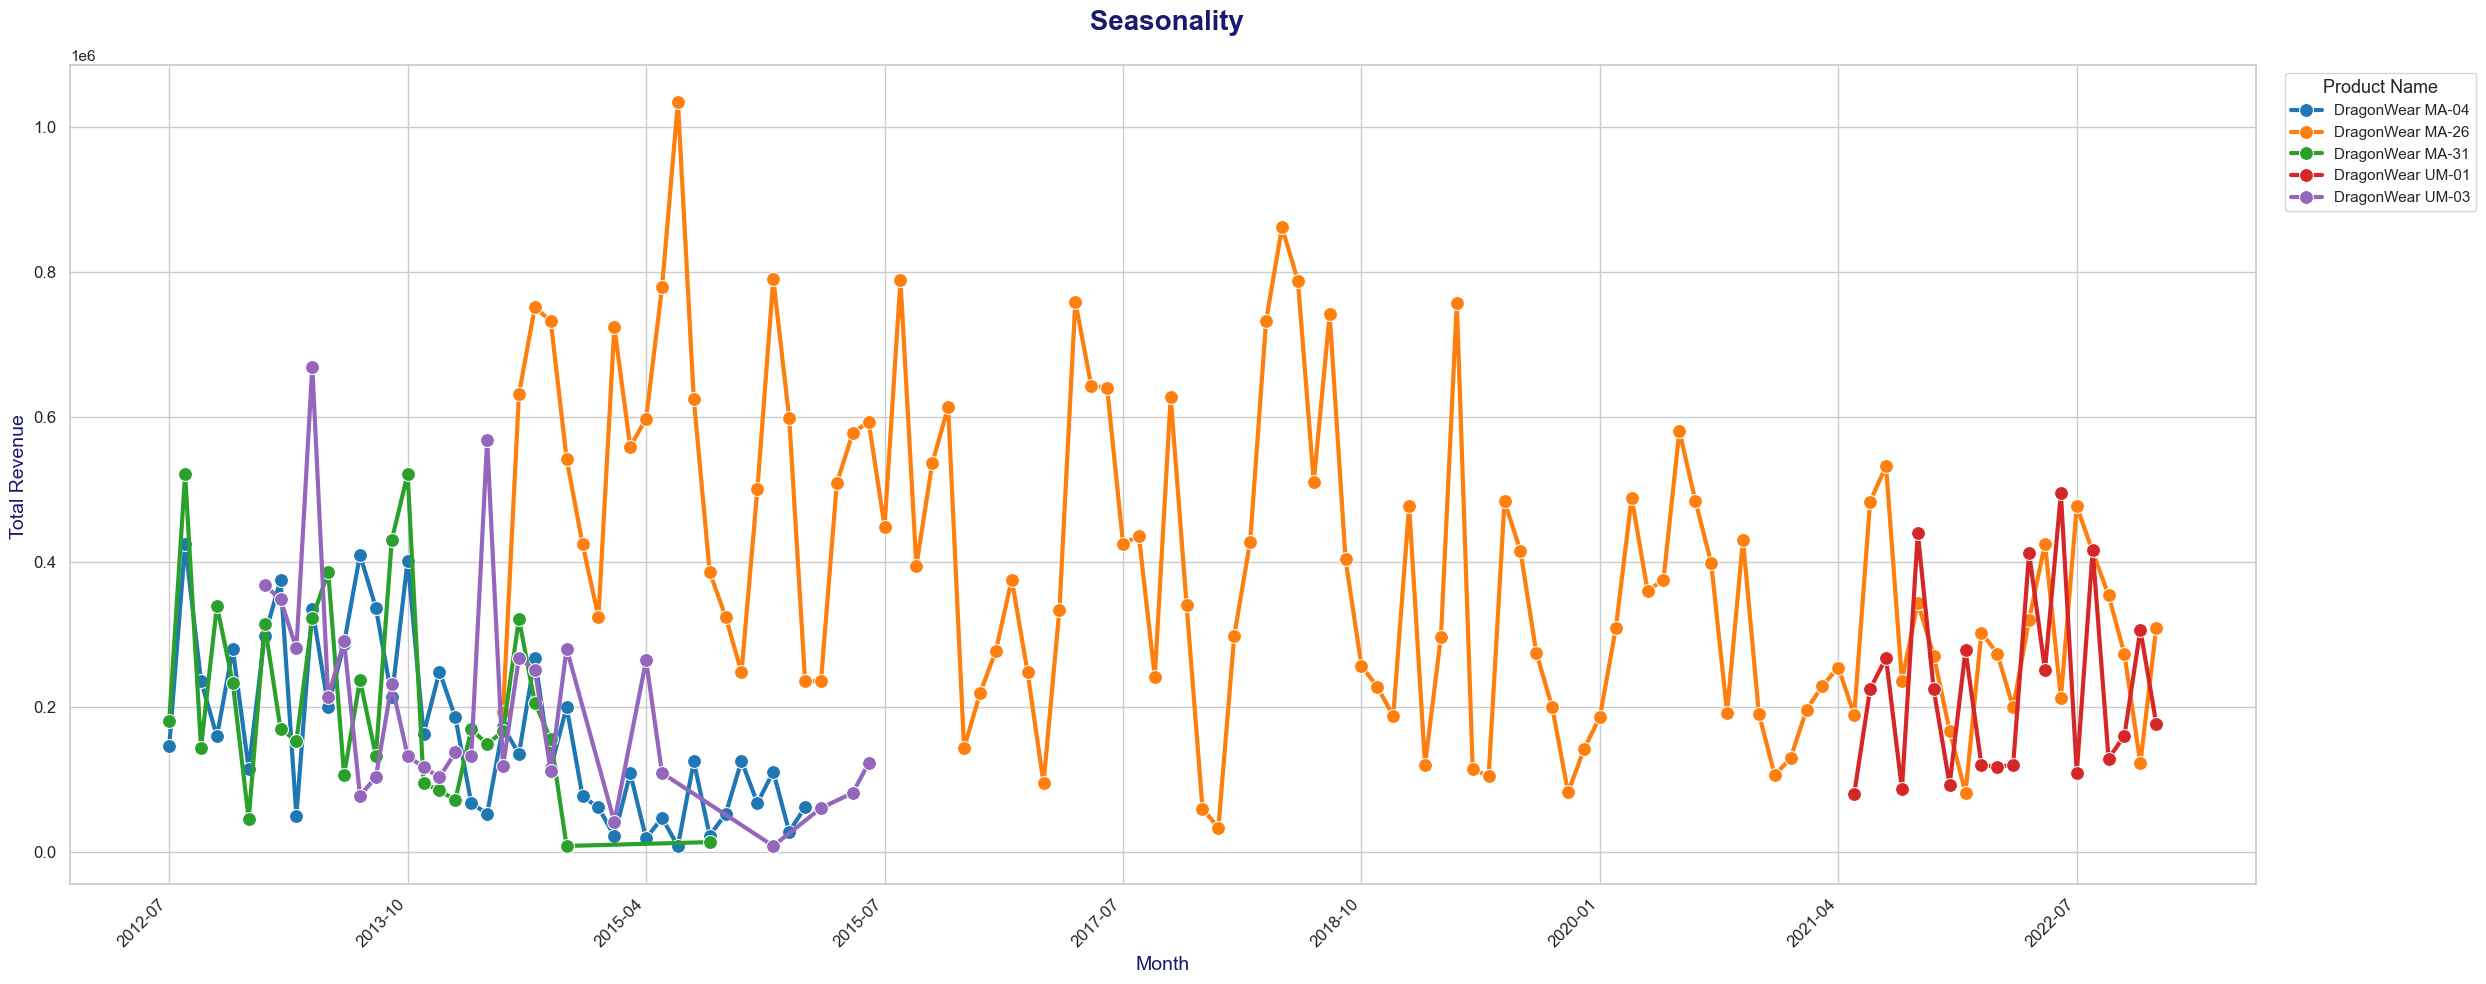

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

top_stars_ids = star_list.head(5)
plot_df = monthly_sales[monthly_sales['product_id'].isin(top_stars_ids)].copy()

plot_df = pd.merge(plot_df, products[['product_id', 'product_name']], on='product_id', how='left')

# Sắp xếp thời gian 
plot_df['month_dt'] = pd.to_datetime(plot_df['month'])
plot_df = plot_df.sort_values(['product_name', 'month_dt'])


plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=plot_df, 
    x='month', 
    y=sales_col, 
    hue='product_name', 
    marker='o', 
    markersize=10,
    palette='tab10', 
    linewidth=3
)

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12)) 

plt.title(' Seasonality', fontsize=20, fontweight='bold', color='midnightblue', pad=25)
plt.xlabel('Month', fontsize=14, color='midnightblue')
plt.ylabel('Total Revenue ', fontsize=14, color='midnightblue')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title='Product Name', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

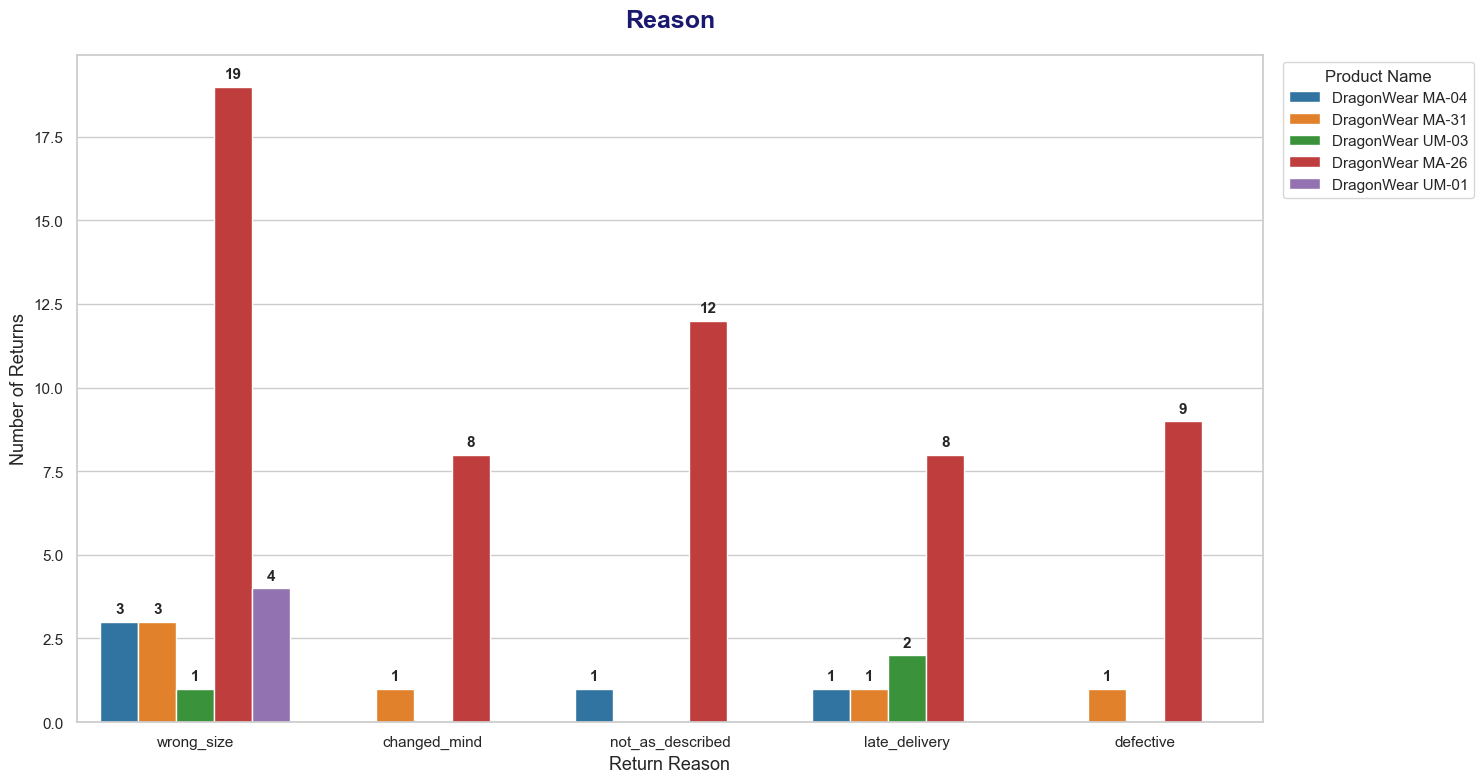

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

star_ids = star_list.head(5)

star_returns = pd.merge(
    returns[returns['product_id'].isin(star_ids)], 
    products[['product_id', 'product_name']], 
    on='product_id'
)

plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=star_returns, 
    x='return_reason', 
    hue='product_name', 
    palette='tab10'
)

plt.title('Reason', 
          fontsize=18, fontweight='bold', color='midnightblue', pad=20)
plt.xlabel('Return Reason', fontsize=13)
plt.ylabel('Number of Returns', fontsize=13)

plt.legend(title='Product Name', bbox_to_anchor=(1.01, 1), loc='upper left')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta


daily_sales = sales_df.groupby('order_date').agg({
    'revenue': 'sum',
    'order_id': 'count'
}).reset_index()
daily_sales.rename(columns={'order_id': 'order_count'}, inplace=True)


def create_features(df):
    df = df.copy()
    
    df['order_date'] = pd.to_datetime(df['order_date'])
    df['day_of_week'] = df['order_date'].dt.dayofweek
    df['month'] = df['order_date'].dt.month
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    for lag in [7, 14, 30]:
        df[f'revenue_lag_{lag}'] = df['revenue'].shift(lag)
    
    df['rolling_mean_7'] = df['revenue'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['revenue'].shift(1).rolling(window=7).std()
    
   
    return df

final_df = create_features(daily_sales)


final_df.dropna(inplace=True)
print(final_df.columns.tolist())

NameError: name 'sales_df' is not defined